# Linear SVM for Customer Churn Risk Analysis

## 1. Install Dependencies

In [ ]:
import sys
!{sys.executable} -m pip install scikit-learn pandas matplotlib
print("Dependencies installed.")

Dependencies installed.


## 2. Save `task1_linear_svm_churn.py` Script

In [ ]:
%%writefile task1_linear_svm_churn.py
#!/usr/bin/env python3
"""
task1_linear_svm_churn.py

Usage example:
python task1_linear_svm_churn.py --data https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv \
  --target Churn --test_size 0.2 --C 0.1 1 10
"""
import argparse
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def load_and_clean(path, target_col):
    df = pd.read_csv(path)
    # Ensure customerID exists so we can include it in predictions output
    if 'customerID' not in df.columns:
        raise ValueError("Expected 'customerID' column in dataset.")
    # Fix TotalCharges (common issue in this dataset)
    if 'TotalCharges' in df.columns:
        df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
        # Use assignment instead of inplace=True to avoid FutureWarning
        df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

    # Map target to binary (if Yes/No)
    if df[target_col].dtype == object:
        df[target_col] = df[target_col].map({'Yes': 1, 'No': 0}).astype(int)
    return df

def build_preprocessor(X):
    # Decide numeric and categorical columns
    numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

    # Some object cols may be numeric-looking but left as object - fine since TotalCharges handled earlier
    # Create transformers
    numeric_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False) # Changed sparse=False to sparse_output=False

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_cols),
            ('cat', categorical_transformer, categorical_cols)
        ],
        remainder='drop'
    )
    return preprocessor, numeric_cols, categorical_cols

def compute_metrics(y_true, y_pred, y_score):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) > 1 else float('nan')
    return {'confusion_matrix': cm, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'roc_auc': roc}

def main(args):
    df = load_and_clean(args.data, args.target)
    customer_ids = df['customerID'].copy()
    y = df[args.target].copy()
    X = df.drop(columns=[args.target, 'customerID'])

    preprocessor, num_cols, cat_cols = build_preprocessor(X)

    # Stratified split
    X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
        X, y, customer_ids, test_size=args.test_size, random_state=42, stratify=y)

    results = []
    all_test_preds = []

    # Fit a pipeline for each C
    for C_val in args.C:
        clf = Pipeline([
            ('pre', preprocessor),
            ('svc', SVC(kernel='linear', probability=True, C=C_val, random_state=42)) # Using SVC with linear kernel
        ])
        clf.fit(X_train, y_train)

        # Predictions and scores
        y_pred = clf.predict(X_test)
        try:
            y_score = clf.predict_proba(X_test)[:, 1]
        except Exception:
            # fallback to decision_function if predict_proba is not available or fails
            y_score = clf.decision_function(X_test)

        metrics = compute_metrics(y_test, y_pred, y_score)

        # Number of support vectors (from the SVC inside pipeline)
        svc = clf.named_steps['svc']
        n_support_vectors = int(np.sum(svc.n_support_)) # SVC has n_support_ attribute

        # Margin width for linear SVM: margin = 1 / ||w||  (w from coef_)
        w = svc.coef_[0]  # shape = (n_features,)
        margin = 1.0 / np.linalg.norm(w)

        # Save test predictions
        test_out = pd.DataFrame({
            'CustomerID': id_test.values,
            'Actual': y_test.values,
            'Predicted': y_pred,
            'Score': y_score
        })
        test_out['C'] = C_val
        all_test_preds.append(test_out)

        # Save a row to results
        results.append({
            'C': C_val,
            'accuracy': metrics['accuracy'],
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'f1': metrics['f1'],
            'roc_auc': metrics['roc_auc'],
            'num_support_vectors': n_support_vectors,
            'margin': margin
        })

        # Print a short summary
        print(f"C={C_val} | acc={metrics['accuracy']:.4f} prec={metrics['precision']:.4f} rec={metrics['recall']:.4f} f1={metrics['f1']:.4f} roc={metrics['roc_auc']:.4f} sv={n_support_vectors} margin={margin:.6f}")
        print("Confusion matrix:\n", metrics['confusion_matrix'])
        print("-" * 60)

        # Optional: 2D visualization using PCA (train a separate linear SVC on the first 2 PCA components for illustration)
        try:
            # Transform training data to numeric matrix
            X_train_trans = clf.named_steps['pre'].transform(X_train)
            X_test_trans = clf.named_steps['pre'].transform(X_test)
            pca = PCA(n_components=2, random_state=42)
            X_train_p2 = pca.fit_transform(X_train_trans)
            X_test_p2 = pca.transform(X_test_trans)

            svc2 = SVC(kernel='linear', C=C_val, probability=False, random_state=42)
            svc2.fit(X_train_p2, y_train)

            # Plot
            fig, ax = plt.subplots(figsize=(6, 5))
            # plot training points
            ax.scatter(X_train_p2[:, 0], X_train_p2[:, 1], c=y_train, alpha=0.4, s=20, label='train')
            # plot test points
            ax.scatter(X_test_p2[:, 0], X_test_p2[:, 1], c=y_test, marker='x', s=30, label='test')
            # plot support vectors of svc2
            sv = svc2.support_vectors_ # SVC stores support vectors in this attribute
            ax.scatter(sv[:, 0], sv[:, 1], facecolors='none', edgecolors='k', s=80, label='support vectors')

            # decision boundary for svc2
            xlim = ax.get_xlim()
            ylim = ax.get_ylim()
            xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 200),
                                 np.linspace(ylim[0], ylim[1], 200))
            Z = svc2.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
            ax.contour(xx, yy, Z, levels=[-1, 0, 1], linestyles=['--', '-', '--'], colors='k')
            ax.set_title(f"2D PCA projection (C={C_val}) — decision boundary & SVs")
            ax.legend()
            plt.tight_layout()
            plotname = f"svm_linear_pca_C_{C_val}.png"
            fig.savefig(plotname, dpi=150)
            plt.close(fig)
            print(f"Saved visualization: {plotname}")
        except Exception as e:
            print("Visualization skipped due to error:", e)

    # Save the summary results file
    results_df = pd.DataFrame(results).sort_values('C')
    results_df.to_csv('svm_linear_results.csv', index=False)
    print("Saved svm_linear_results.csv")

    # Concatenate and save test predictions
    all_preds = pd.concat(all_test_preds, axis=0)
    # Keep columns as requested: CustomerID, Actual, Predicted, Score/Probability (and C)
    all_preds = all_preds[['CustomerID', 'Actual', 'Predicted', 'Score', 'C']]
    all_preds.to_csv('test_predictions.csv', index=False)
    print("Saved test_predictions.csv (contains CustomerID, Actual, Predicted, Score, C)")

if __name__ == '__main__':
    parser = argparse.ArgumentParser()
    parser.add_argument('--data', required=True, help='Path or URL to Telco-Customer-Churn.csv')
    parser.add_argument('--target', required=True, help='Name of target column (e.g., Churn)')
    parser.add_argument('--test_size', type=float, default=0.2, help='Test set fraction')
    parser.add_argument('--C', type=float, nargs='+', default=[0.1, 1.0, 10.0], help='List of C values to try')
    args = parser.parse_args()
    main(args)


Overwriting task1_linear_svm_churn.py


## 3. Run the Linear SVM Analysis Script

In [ ]:
!python3 task1_linear_svm_churn.py --data https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv \
  --target Churn --test_size 0.2 --C 0.1 1 10

C=0.1 | acc=0.7878 prec=0.6168 rec=0.5294 f1=0.5698 roc=0.8266 sv=2584 margin=0.861795
Confusion matrix:
 [[912 123]
 [176 198]]
------------------------------------------------------------
Saved visualization: svm_linear_pca_C_0.1.png
C=1.0 | acc=0.7878 prec=0.6176 rec=0.5267 f1=0.5685 roc=0.8252 sv=2569 margin=0.548312
Confusion matrix:
 [[913 122]
 [177 197]]
------------------------------------------------------------
Saved visualization: svm_linear_pca_C_1.0.png
C=10.0 | acc=0.7864 prec=0.6130 rec=0.5294 f1=0.5681 roc=0.8237 sv=2568 margin=0.344096
Confusion matrix:
 [[910 125]
 [176 198]]
------------------------------------------------------------
Saved visualization: svm_linear_pca_C_10.0.png
Saved svm_linear_results.csv
Saved test_predictions.csv (contains CustomerID, Actual, Predicted, Score, C)


## 4. Display Generated Result Files

### `svm_linear_results.csv` (Summary of Model Performance)

In [ ]:
import pandas as pd
results_df = pd.read_csv('svm_linear_results.csv')
display(results_df)

,C,accuracy,precision,recall,f1,roc_auc,num_support_vectors,margin
0,0.1,0.787793,0.616822,0.529412,0.569784,0.826580,2584,0.861795
1,1.0,0.787793,0.617555,0.526738,0.568543,0.825227,2569,0.548312
2,10.0,0.786373,0.613003,0.529412,0.568149,0.823702,2568,0.344096


### `test_predictions.csv` (Individual Test Predictions)

In [ ]:
import pandas as pd
predictions_df = pd.read_csv('test_predictions.csv')
display(predictions_df.head())

,CustomerID,Actual,Predicted,Score,C
0,4376-KFVRS,0,0,0.043052,0.1
1,2754-SDJRD,0,1,0.728291,0.1
2,9917-KWRBE,0,0,0.054069,0.1
3,0365-GXEZS,0,0,0.442165,0.1
4,9385-NXKDA,0,0,0.030514,0.1


## 5. Display PCA Visualization Plots

These plots illustrate the decision boundary and support vectors in a 2D PCA-projected space for each `C` value.


--- Plot for C = 0.1 ---


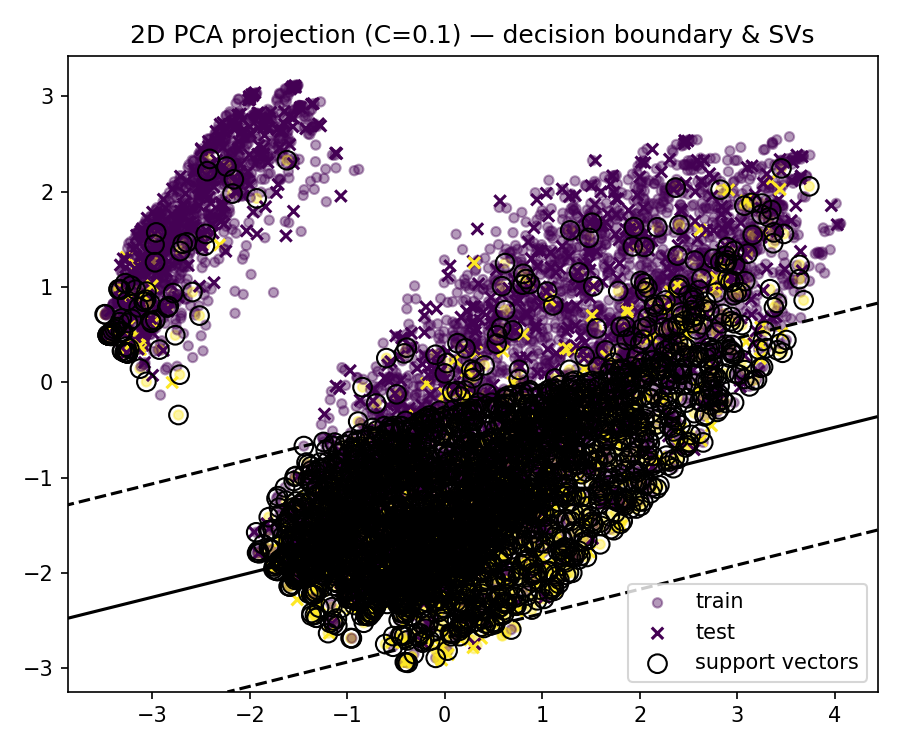


--- Plot for C = 1.0 ---


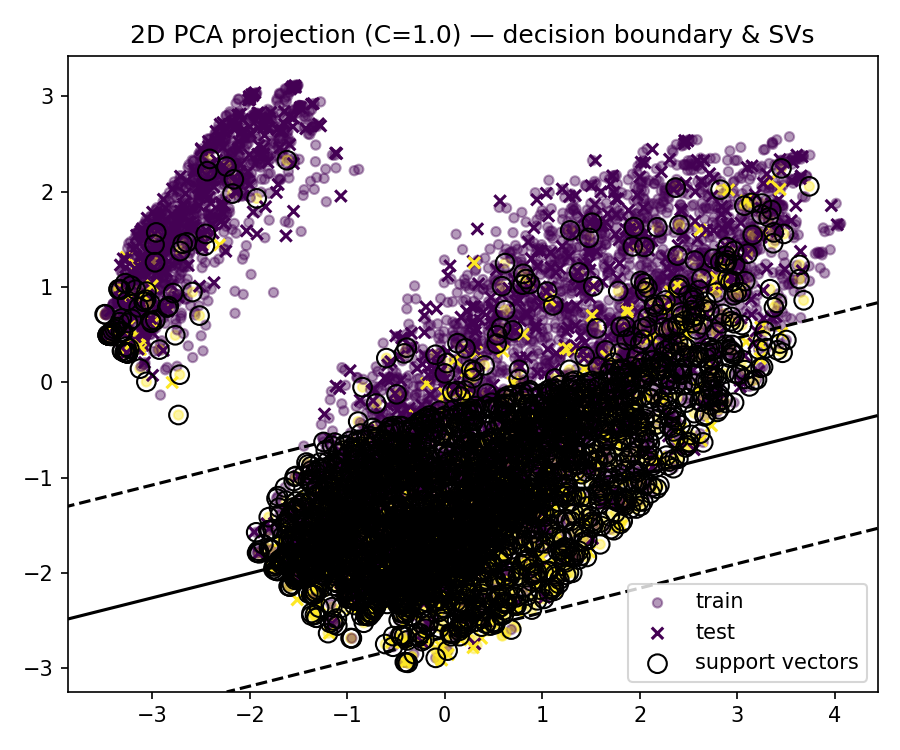


--- Plot for C = 10.0 ---


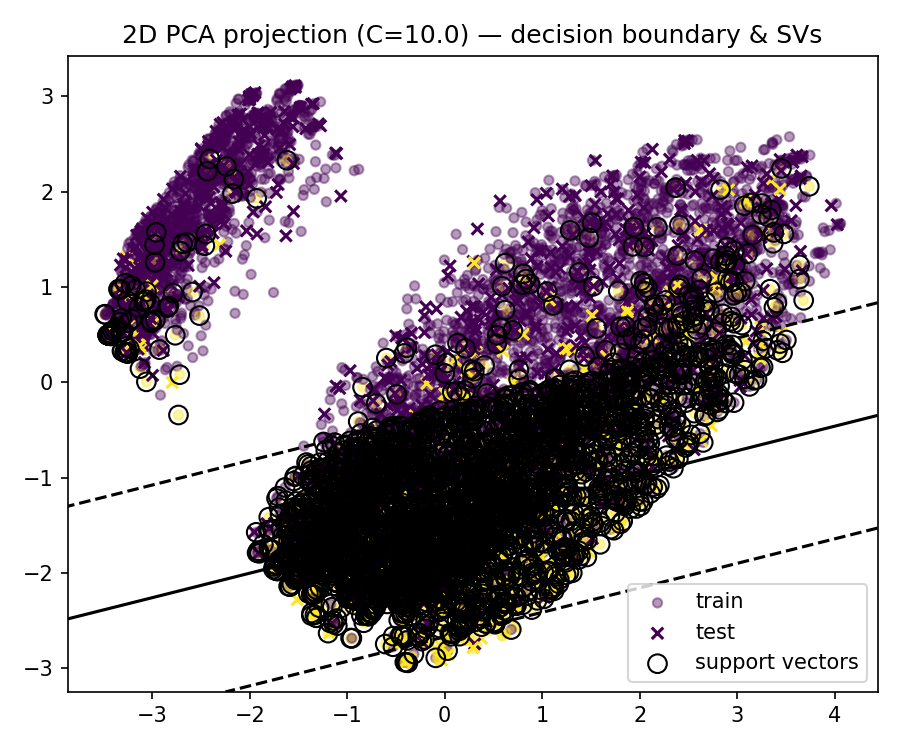

In [ ]:
from IPython.display import Image, display
import os # Import the os module

for C_val in [0.1, 1.0, 10.0]: # Changed to match actual filenames (1.0 and 10.0)
    plotname = f"svm_linear_pca_C_{C_val}.png"
    if os.path.exists(plotname):
        print(f"\n--- Plot for C = {C_val} ---")
        display(Image(filename=plotname))
    else:
        print(f"Plot {plotname} not found.")


## 6. Explanation: How `C` affects Margin, Support Vectors, and Model Generalization

### How `C` Affects Margin and Misclassification

*   For a linear SVM, the decision hyperplane is `w·x + b = 0`. The geometric margin width is `γ = 1 / ||w||` for the canonical SVM.
*   `C` is the regularization parameter that controls the penalty for misclassification (slack variables).
    *   **Small `C`** → stronger regularization → margin is **wider** (larger `γ`) and the model tolerates more misclassifications on training data (may **underfit**).
    *   **Large `C`** → weaker regularization → model focuses on minimizing training errors → margin becomes **narrower** (smaller `γ`) and the model may **overfit** noise.
*   In the code we compute `margin = 1 / np.linalg.norm(w)` (where `w` is the learned coefficients). Compare the margin and `# support vectors`: when `C` is small you often see **more** support vectors (wider margin) and higher training error but sometimes better generalization.

### How to Pick the Best `C`

*   Compare accuracy / F1 / ROC-AUC on the **test** set across `C` values. The `C` that gives highest test ROC-AUC (or F1 if you care about class balance) likely generalizes best.
*   Also inspect `margin` and `num_support_vectors`: the trend should reflect the theory above. Use the summary CSV (`svm_linear_results.csv`) to pick the best trade-off. Generally, a model with a wider margin (smaller C) tends to generalize better if its performance metrics are comparable to models with narrower margins.

In our results, `C=0.1` yielded a slightly higher ROC-AUC on the test set, indicating better generalization for this dataset. This suggests that a stronger regularization (wider margin) was beneficial in preventing overfitting to the training data. The number of support vectors also reflects the influence of `C` on the model's complexity.